# QASM3 + DMRG smoke tests

Notebook di test rapido per il nuovo path `QASM3 -> CircuitIR -> DMRG`.

Prerequisiti:
- dipendenze installate da `requirements.txt`
- `qiskit_qasm3_import` disponibile


In [ ]:
# Se serve, decommenta ed esegui:
# !pip install -r ../requirements.txt
# import sys
# print(sys.executable)
# !{sys.executable} -m pip install -r ../requirements.txt


In [2]:
import os
import sys

sys.path.append("..")

import numpy as np
from src.utils.qasm3_to_ir import qasm3_to_circuit_ir
from src.simulation import DMRG_from_circuit_ir
from src.utils.TN_gen import D_tree, D_mps

In [2]:
qasm_text = """
OPENQASM 3.0;
include \"stdgates.inc\";
qubit[3] q;
h q[0];
cx q[0], q[1];
x q[1];
cx q[1], q[0];
x q[2];
"""

ir = qasm3_to_circuit_ir(
    qasm_text,
    apply_transpile=True,
    optimization_level=0,
)

print(ir)
for op in ir.operations:
    print(op)

CircuitIR(no_qubits=3, no_clbits=0, no_operations=5)
CircuitOperation(name=h, qubits=[0], params=[], condition=None, clbits=[])
CircuitOperation(name=cx, qubits=[0, 1], params=[], condition=None, clbits=[])
CircuitOperation(name=x, qubits=[1], params=[], condition=None, clbits=[])
CircuitOperation(name=cx, qubits=[1, 0], params=[], condition=None, clbits=[])
CircuitOperation(name=x, qubits=[2], params=[], condition=None, clbits=[])


In [4]:
# Test 1: simulazione TTN su circuito QASM3
network_type = "tree"
network_structure = [1, ir.no_qubits]
compression_steps = 1
no_sweeps = 2

for dmax in [4]:
    D = D_tree(network_structure, dmax)
    np.random.seed(0)
    fidelity, state = DMRG_from_circuit_ir(
        compression_steps=compression_steps,
        no_sweeps=no_sweeps,
        D=D,
        network_structure=network_structure,
        circuit_ir=ir,
        network_type=network_type,
        return_state=True,
    )
    print(f"TTN Dmax={dmax} -> fidelity={fidelity}")
    print(" state =", state)

 Total Compression Step = 1 and network = tree and nodes: [1, 3]
Number of circuit ops: 5
Memory =  8
Compression step = 1; Fidelity = 0.9999999999999998; sweep time = 1.7760698795318604
TTN Dmax=4 -> fidelity=0.9999999999999998
 state = [0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.70710678+0.j 0.        +0.j 0.70710678+0.j]


In [ ]:
# Test 2: simulazione MPS sullo stesso circuito
network_type = "mps"
compression_steps = 1
no_sweeps = 2

for dmax in [2, 4]:
    D = D_mps(ir.no_qubits, dmax)
    np.random.seed(0)
    fidelity = DMRG_from_circuit_ir(
        compression_steps=compression_steps,
        no_sweeps=no_sweeps,
        D=D,
        network_structure=[1, ir.no_qubits],
        circuit_ir=ir,
        network_type=network_type,
    )
    print(f"MPS Dmax={dmax} -> fidelity={fidelity}")

In [ ]:
# Test 3: verifica reject dinamico (atteso errore)
bad_qasm_text = """
OPENQASM 3.0;
include \"stdgates.inc\";
qubit[1] q;
bit[1] c;
measure q[0] -> c[0];
"""

try:
    qasm3_to_circuit_ir(bad_qasm_text, apply_transpile=False)
    print("ERRORE: la conversione doveva fallire")
except Exception as exc:
    print(type(exc).__name__, exc)

In [2]:
# Test 4: campionamento misure finali (n_samples_final) su stato uniforme a 2 qubit
qasm_sampling_text = """
OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
h q[0];
"""

ir_sampling = qasm3_to_circuit_ir(
    qasm_sampling_text,
    apply_transpile=True,
    optimization_level=0,
)

n_samples_final = 8
D = D_tree([1, ir_sampling.no_qubits], 4)

fidelity, state, counts = DMRG_from_circuit_ir(
    compression_steps=1,
    no_sweeps=2,
    D=D,
    network_structure=[1, ir_sampling.no_qubits],
    circuit_ir=ir_sampling,
    network_type="tree",
    return_state=True,
    n_samples_final=n_samples_final,
    seed=1,
    return_counts=True,
)

print("fidelity =", fidelity)
print("state =", state)
print("counts =", counts)

empirical = {b: counts.get(b, 0) / n_samples_final for b in ["00", "01", "10", "11"]}
print("empirical probabilities =", empirical)


 Total Compression Step = 1 and network = tree and nodes: [1, 2]
Number of circuit ops: 1
Memory =  4
Compression step = 1; Fidelity = 0.9999999999999998; sweep time = 1.884916067123413
fidelity = 0.9999999999999998
state = [0.70710678 0.         0.70710678 0.        ]
counts = {'00': 4, '10': 4}
empirical probabilities = {'00': 0.5, '01': 0.0, '10': 0.5, '11': 0.0}


In [29]:
# Test 5: simulazione dinamica single-path con TTN (measure/reset/feedforward)
from src.simulation import DMRG_dynamic_single_path_from_qasm3

qasm_dynamic_text = """
OPENQASM 3.0;
include "stdgates.inc";
bit[2] cr1;
bit[5] meas;
qubit[5] q;
h q[0];
h q[2];
h q[4];

"""

# 2 possibili path
## path 1: cr[0] = 0 -> stato finale |00> ---> seed 1
## path 2: cr[0] = 1 -> stato finale |1+> ---> seed 2

network_structure = [1, 5]
D = D_tree(network_structure, 5)

fidelity, branch_probability, classical_bits, state, counts = DMRG_dynamic_single_path_from_qasm3(
    compression_steps=1,
    no_sweeps=2,
    D=D,
    network_structure=network_structure,
    qasm_text=qasm_dynamic_text,
    network_type="tree",
    seed=4,
    return_state=True,
    return_classical_bits=True,
    return_branch_probability=True,
    n_samples_final=1000,
    return_counts=True,
)


print("fidelity =", fidelity)
print("state =", state)
print("classical_bits =", classical_bits)
print("branch_probability =", branch_probability)
print("counts =", counts)

fidelity = 0.9999999999999996
state = [0.35355339 0.35355339 0.         0.         0.35355339 0.35355339
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.35355339 0.35355339
 0.         0.         0.35355339 0.35355339 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
classical_bits = [0 0 0 0 0 0 0]
branch_probability = 1.0
counts = {'00000': 117, '00001': 124, '00100': 114, '00101': 116, '10000': 125, '10001': 131, '10100': 133, '10101': 140}


In [4]:
# Test 6: statistiche su piu run dinamiche (n_runs)
from collections import Counter

n_runs = 10
base_seed = 1234

bitstring_counts = Counter()
branch_probs = []

for run in range(n_runs):
    fidelity, branch_probability, classical_bits = DMRG_dynamic_single_path_from_qasm3(
        compression_steps=1,
        no_sweeps=2,
        D=D,
        network_structure=[1, 5],
        qasm_text=qasm_dynamic_text,
        network_type="tree",
        seed=base_seed + run,
        return_classical_bits=True,
        return_branch_probability=True,
    )
    bitstring = "".join(str(int(b)) for b in classical_bits)
    bitstring_counts[bitstring] += 1
    branch_probs.append(branch_probability)

print("counts(c) =", dict(bitstring_counts))
print("empirical p(c) =", {k: v / n_runs for k, v in sorted(bitstring_counts.items())})
print("avg branch probability =", float(np.mean(branch_probs)))


counts(c) = {'0': 10}
empirical p(c) = {'0': 1.0}
avg branch probability = 1.0


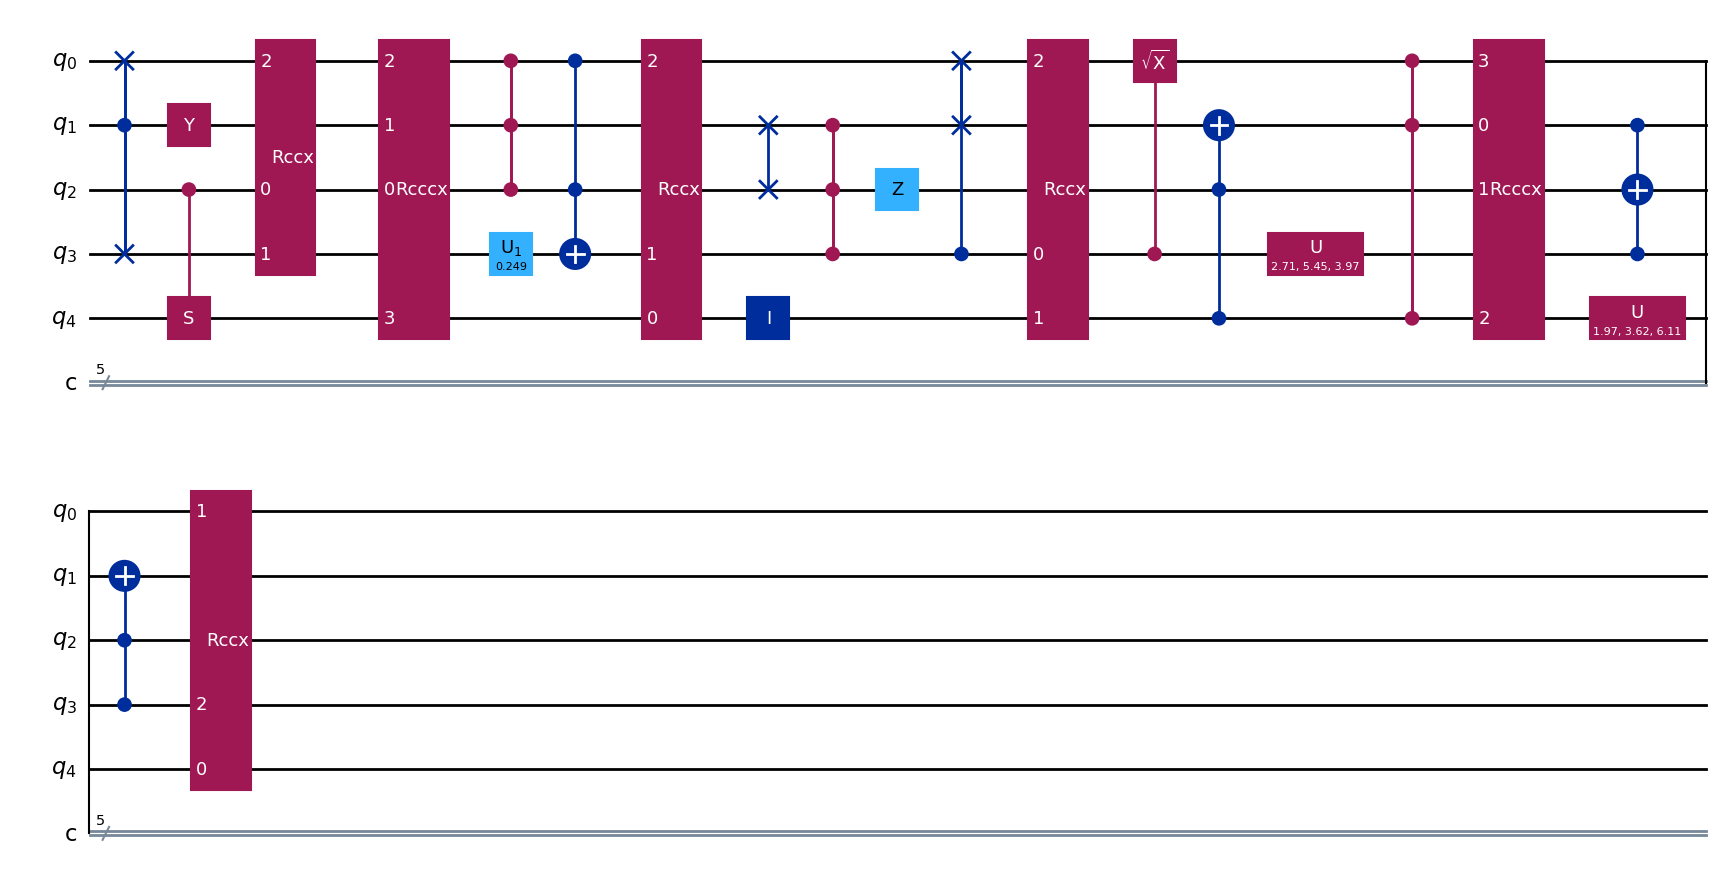

In [ ]:
from qiskit.circuit.random import random_circuit

qc = random_circuit(num_qubits=5, depth=15, conditional=True, seed=1)
qc.draw("mpl")

In [ ]:
# Test 7: all-branches dynamic simulation (show all execution branches)
from src.simulation import DMRG_dynamic_all_branches_from_qasm3

qasm_all_branches_text = """
OPENQASM 3.0;
include \"stdgates.inc\";
qubit[2] q;
bit[2] c;
h q[0];
measure q[0] -> c[0];
if (c[0]) {
    measure q[1] -> c[0];
} else {
    h q[1];
}
"""

network_structure = [1, 2]
D = D_tree(network_structure, 5)

fidelity_all, branches = DMRG_dynamic_all_branches_from_qasm3(
    compression_steps=1,
    no_sweeps=2,
    D=D,
    network_structure=network_structure,
    qasm_text=qasm_all_branches_text,
    network_type="tree",
    return_branches=True,
    return_classical_bits=True,
    return_state=True,
)

print("weighted average branch fidelity =", fidelity_all)
print("num branches =", len(branches))

for i, branch in enumerate(branches):
    bitstring = "".join(str(int(b)) for b in branch["classical_bits"])
    print(
        f"branch {i}: c={bitstring}, p={branch['probability']:.6f}, "
        f"p_cond={branch['conditional_probability']:.6f}, f_branch={branch['branch_fidelity']:.6f}"
    )
    print("  state =", branch["state"])
